In [ ]:
# Problem 2 - KNN Classification: Loan Default Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm EmploymentType  loan
0   28           6.5          720           5         5       Salaried     0
1   45          12.0          680          10        10  Self-Employed     1
2   35           8.0          750           6         7       Salaried     0
3   50          15.0          640          12        15  Self-Employed     1
4   30           7.0          710           5         5       Salaried     0

Shape: (10, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10 non-null     int64  
 1   AnnualIncome    10 non-null     float64
 2   CreditScore     10 non-null     int64  
 3   LoanAmount      10 non-null     int64  
 4   LoanTerm        10 non-null     int64  
 5   EmploymentType  10 non-null     object 
 6   loan            10 non-null     int64  
dtypes: float64(

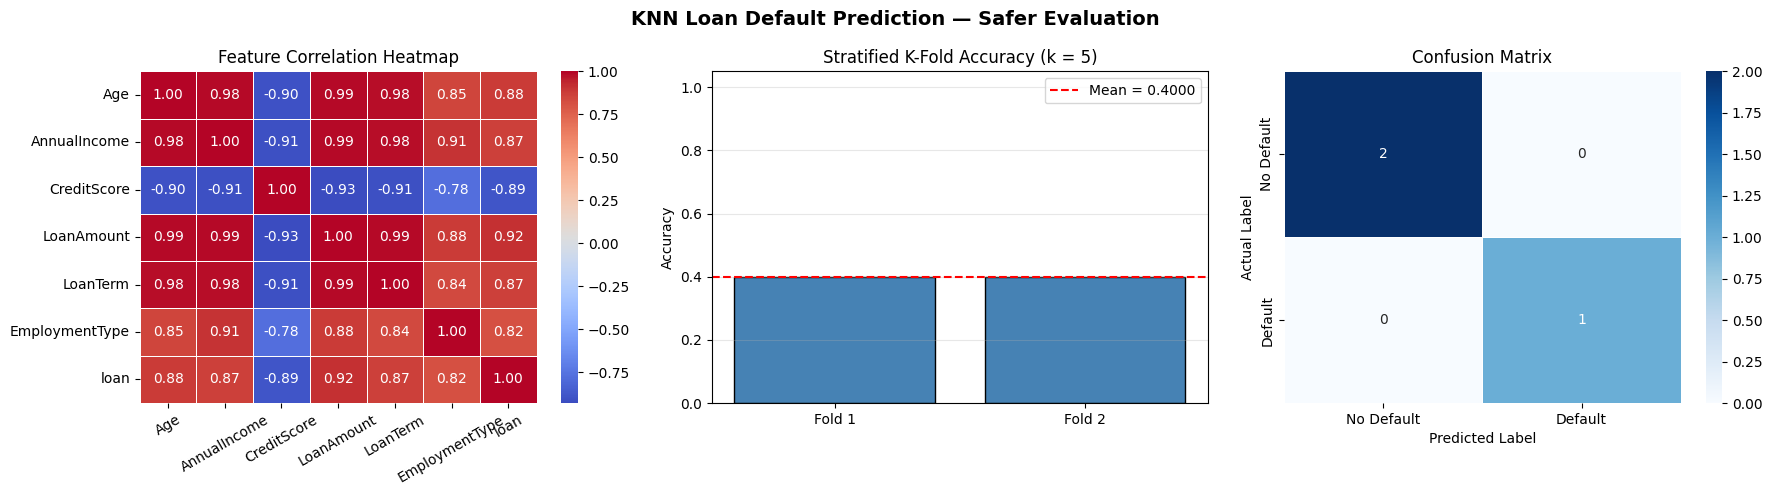

In [ ]:
data = {
    "Age": [28, 45, 35, 50, 30, 42, 26, 48, 38, 55],
    "AnnualIncome": [6.5, 12, 8, 15, 7, 10, 5.5, 14, 9, 16],
    "CreditScore": [720, 680, 750, 640, 710, 660, 730, 650, 700, 620],
    "LoanAmount": [5, 10, 6, 12, 5, 9, 4, 11, 7, 13],
    "LoanTerm": [5, 10, 7, 15, 5, 10, 4, 12, 8, 15],
    "EmploymentType": [
        "Salaried", "Self-Employed", "Salaried", "Self-Employed", "Salaried",
        "Salaried", "Salaried", "Self-Employed", "Salaried", "Self-Employed"
    ],
    "loan": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
}

df = pd.DataFrame(data)

print(df.head())
print(f"\nShape: {df.shape}")
df.info()
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

# encode the categorical employment column
le = LabelEncoder()
df["EmploymentType"] = le.fit_transform(df["EmploymentType"])

X = df.drop("loan", axis=1)
y = df["loan"]

# split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_value = 5
knn = KNeighborsClassifier(n_neighbors=k_value)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# 2-fold CV using a pipeline so scaling stays inside each fold
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k_value))
])

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X, y, cv=skf, scoring="accuracy")

print(f"\nFold Accuracies : {np.round(cv_scores, 4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std CV Accuracy : {cv_scores.std():.4f}")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0,
    target_names=["No Default", "Default"]
))

# predict on the full dataset to flag high-risk customers
X_all_scaled = scaler.transform(X)
all_preds = knn.predict(X_all_scaled)

df_display = df.copy()
df_display["EmploymentType"] = df_display["EmploymentType"].map({
    0: "Salaried",
    1: "Self-Employed"
})
df_display["Predicted_Default"] = all_preds

high_risk = df_display[df_display["Predicted_Default"] == 1]
print("\nHigh-Risk Customers (Predicted Default = 1):")
print(high_risk[
    ["Age", "AnnualIncome", "CreditScore", "LoanAmount",
     "LoanTerm", "EmploymentType", "loan", "Predicted_Default"]
].to_string(index=True))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("KNN Loan Default Prediction — Safer Evaluation", fontsize=14, fontweight="bold")

corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Feature Correlation Heatmap")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(
    [f"Fold {i+1}" for i in range(len(cv_scores))],
    cv_scores,
    color="steelblue",
    edgecolor="black"
)
axes[1].axhline(cv_scores.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Mean = {cv_scores.mean():.4f}")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Stratified K-Fold Accuracy (k = 5)")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[2],
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("Actual Label")
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()